# SocialGood

In [2]:
import numpy as np

dir_path1 = "./output/FFSr"
file_path1 = "./output/FFSr/test_results.npz"
dir_path2 = "./output/FFSr"
file_path2 = "./output/FFSr/test_results.npz"

with np.load(file_path1) as data:
    result1 = {key: data[key] for key in data.files}

with np.load(file_path2) as data:
    result2 = {key: data[key] for key in data.files}

print(result1['input_seq'].shape)
print(result1['selected_experts'].shape)

num_experts = 4; patch_len = 4

selected_experts = result1['selected_experts'].astype(int)
flattened = selected_experts.reshape(-1, selected_experts.shape[-1])
all_expert_indices = flattened.flatten()  
expert_freq = np.bincount(all_expert_indices, minlength=num_experts)
print("Expert selection frequency:")
for i in range(num_experts):
    print(f"  Expert {i}: {expert_freq[i]} times")

selected_experts = result2['selected_experts'].astype(int)
flattened = selected_experts.reshape(-1, selected_experts.shape[-1])
all_expert_indices = flattened.flatten()  
expert_freq = np.bincount(all_expert_indices, minlength=num_experts)
print("Expert selection frequency:")
for i in range(num_experts):
    print(f"  Expert {i}: {expert_freq[i]} times")

(184, 1, 312)
(184, 78, 2)
Expert selection frequency:
  Expert 0: 6044 times
  Expert 1: 8245 times
  Expert 2: 14352 times
  Expert 3: 63 times
Expert selection frequency:
  Expert 0: 6044 times
  Expert 1: 8245 times
  Expert 2: 14352 times
  Expert 3: 63 times


Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_1.pdf


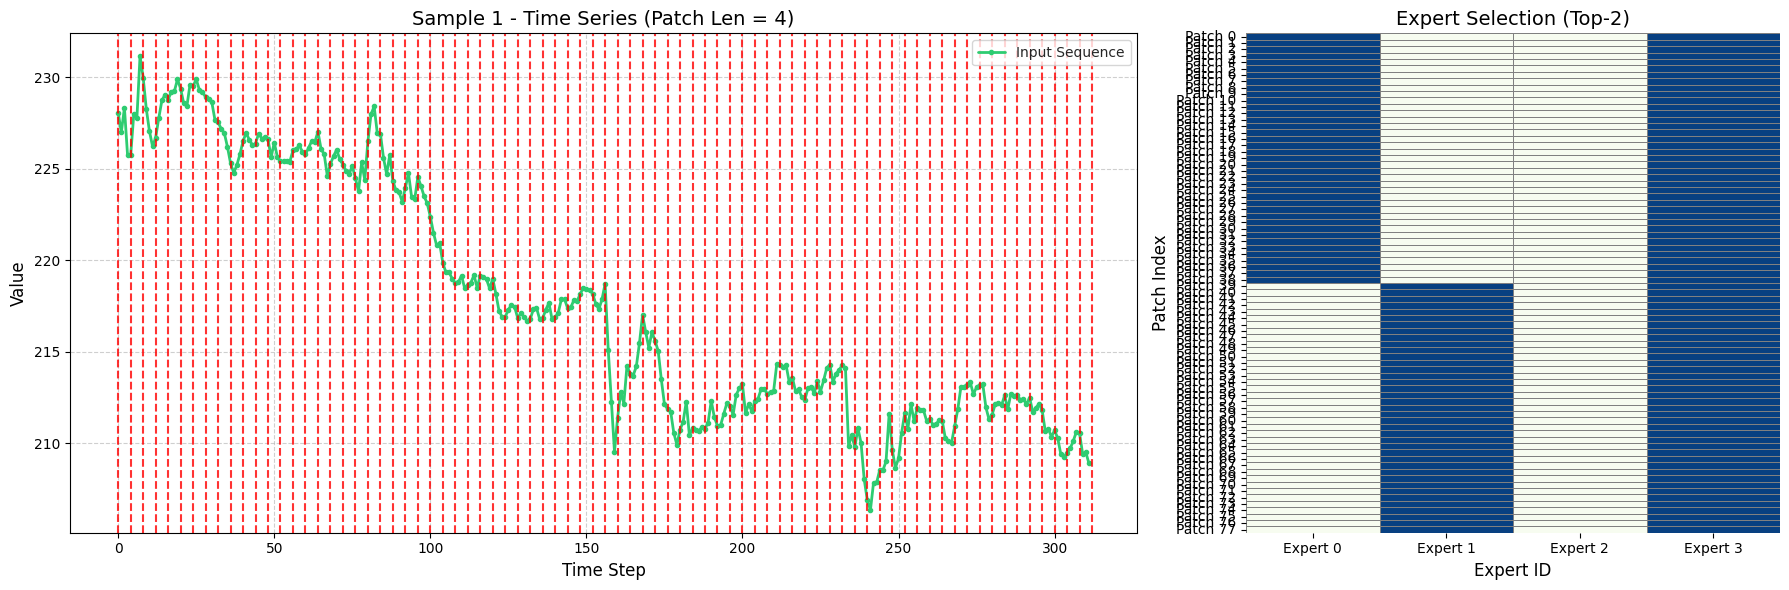

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_2.pdf


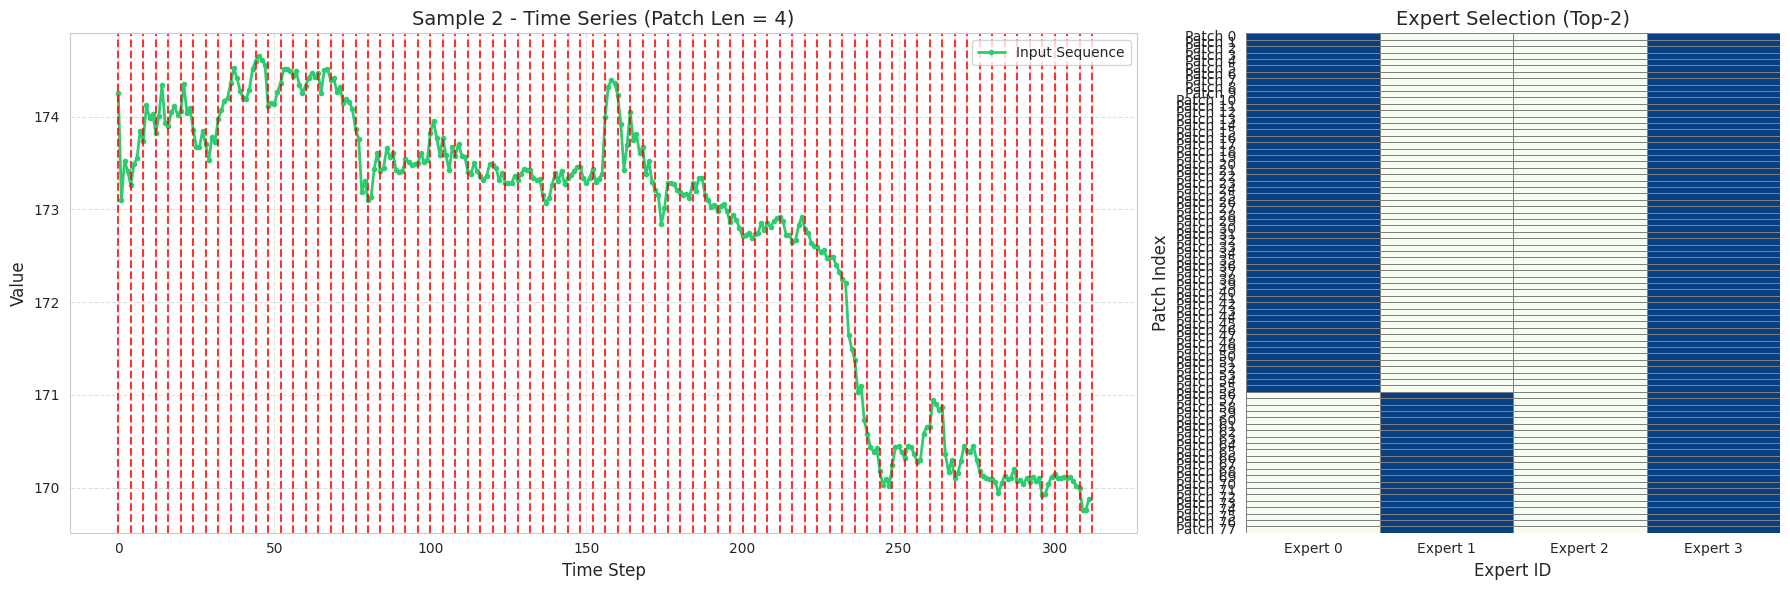

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_3.pdf


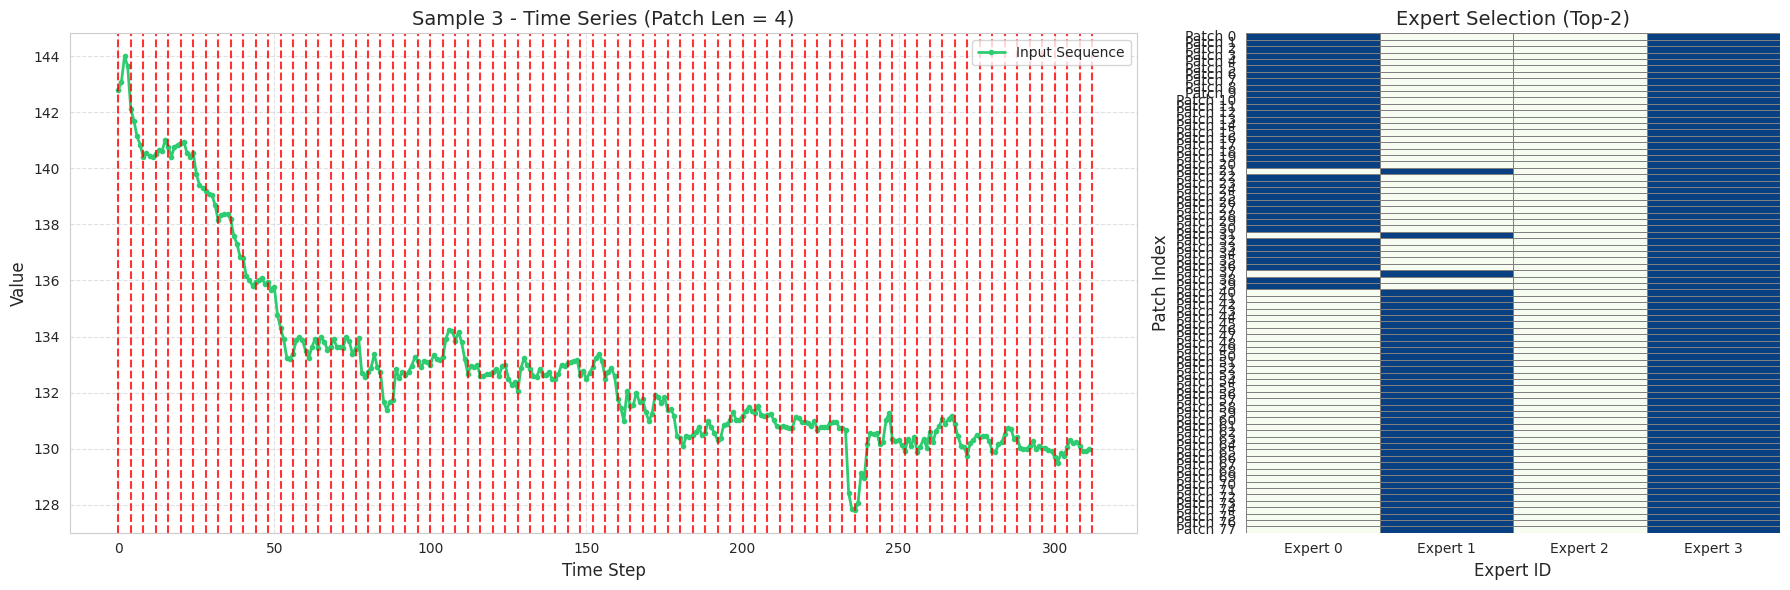

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_8.pdf


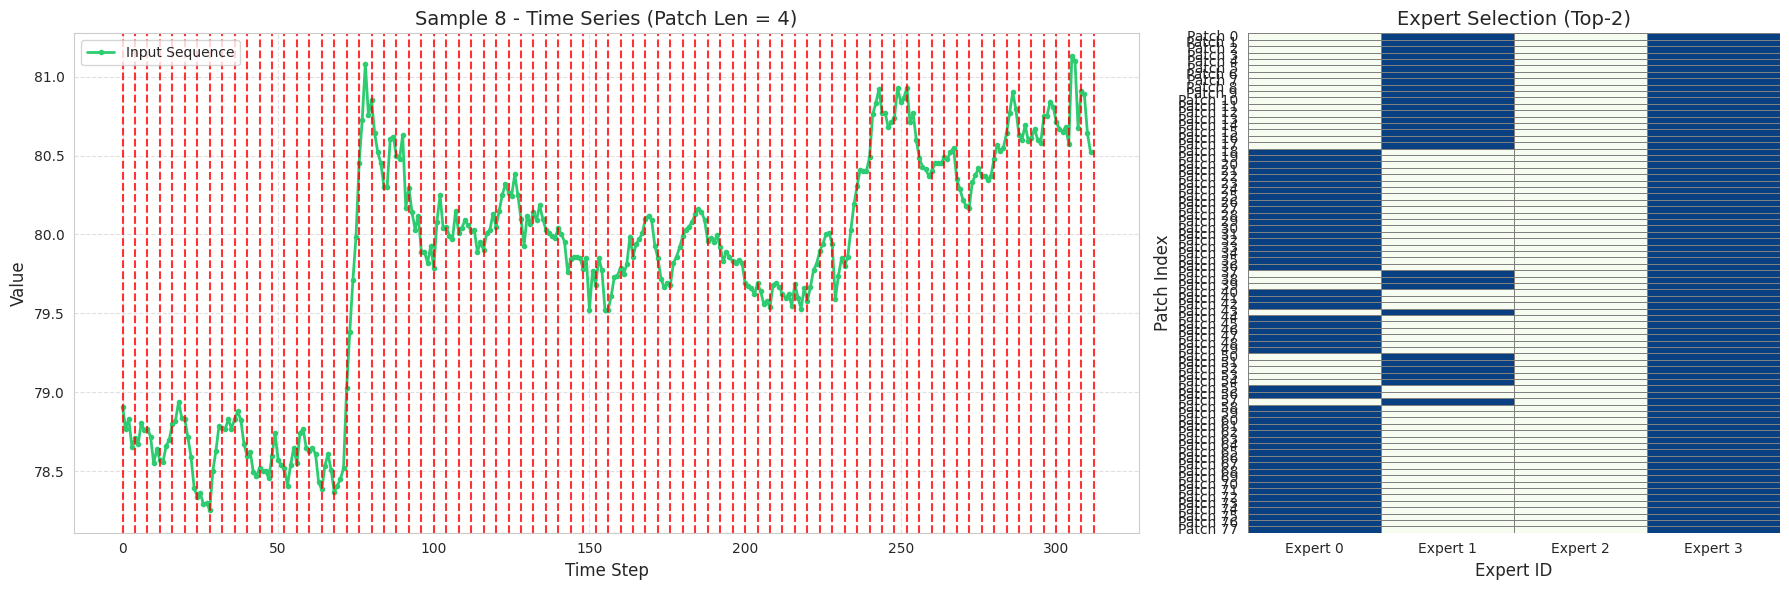

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_10.pdf


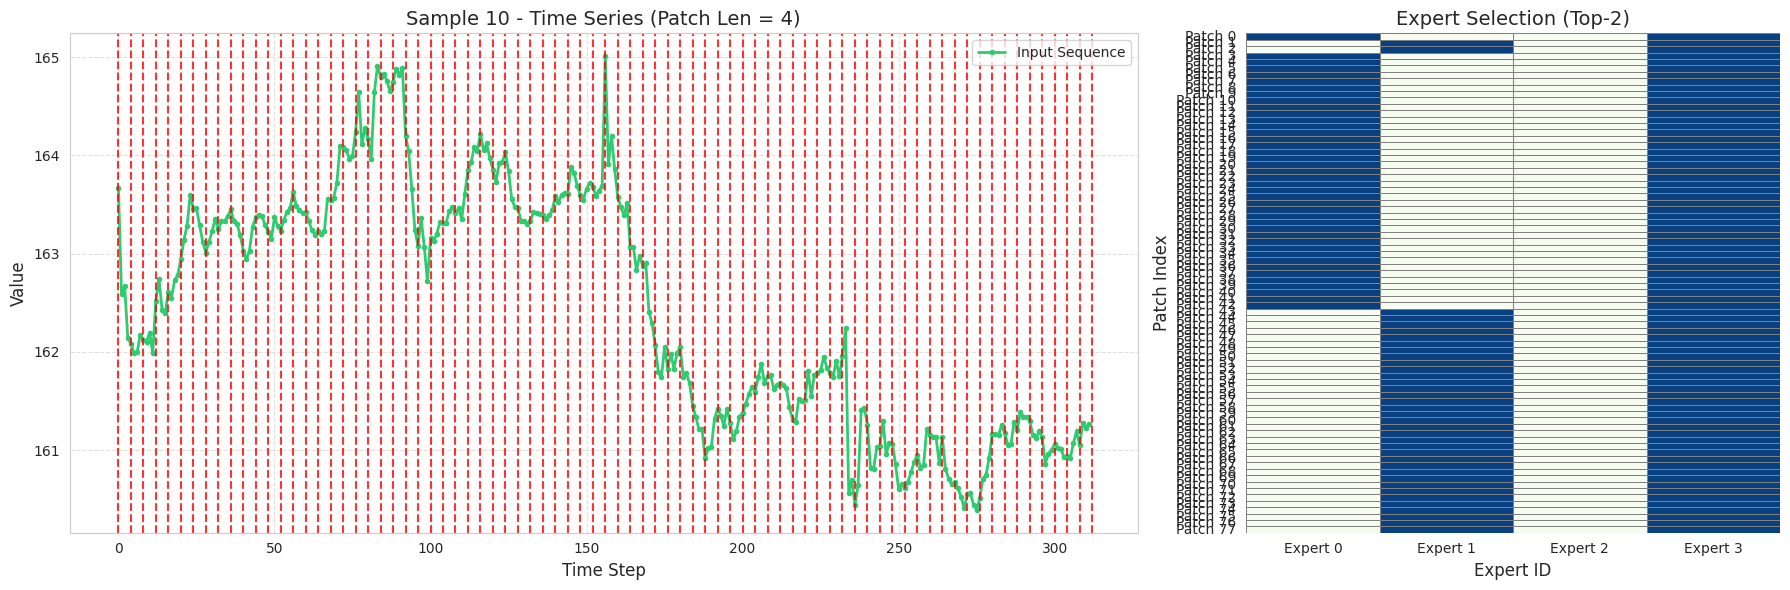

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_15.pdf


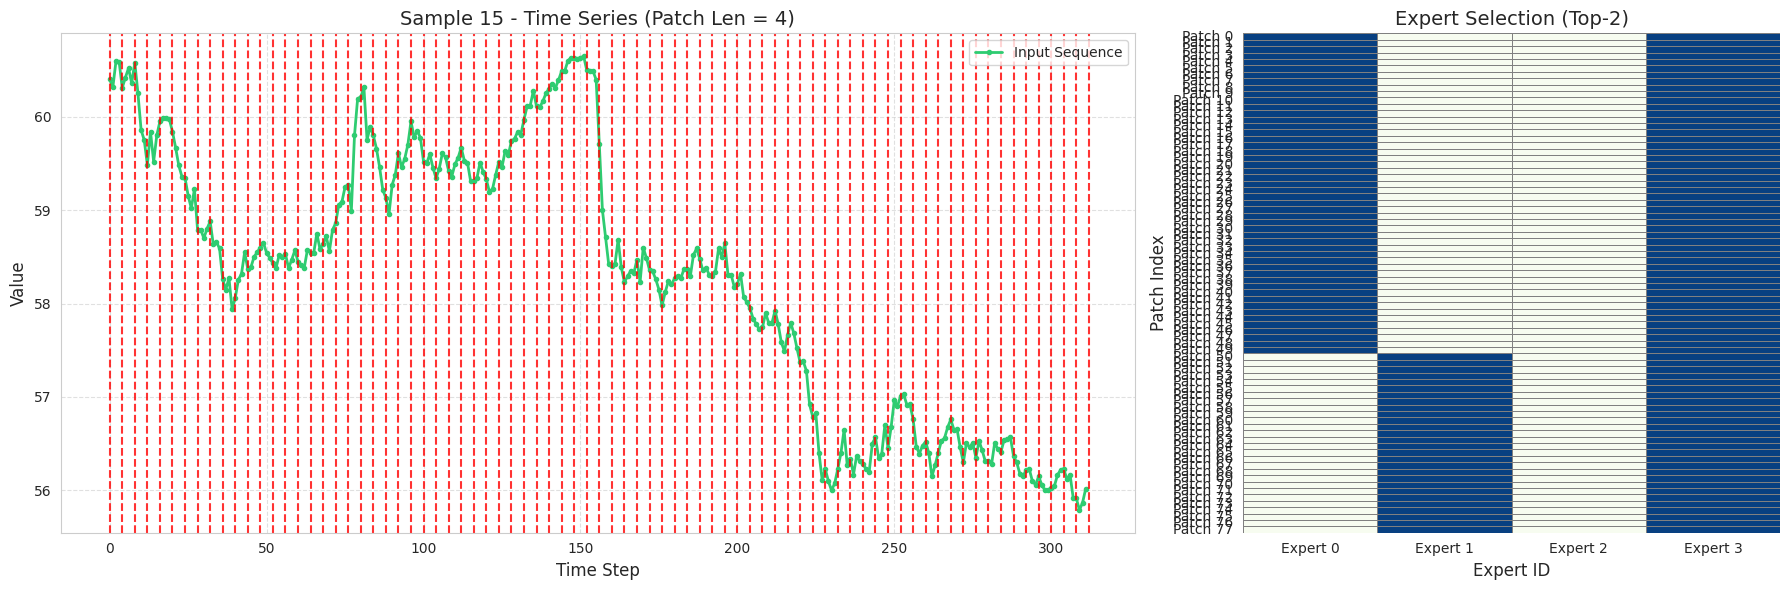

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_20.pdf


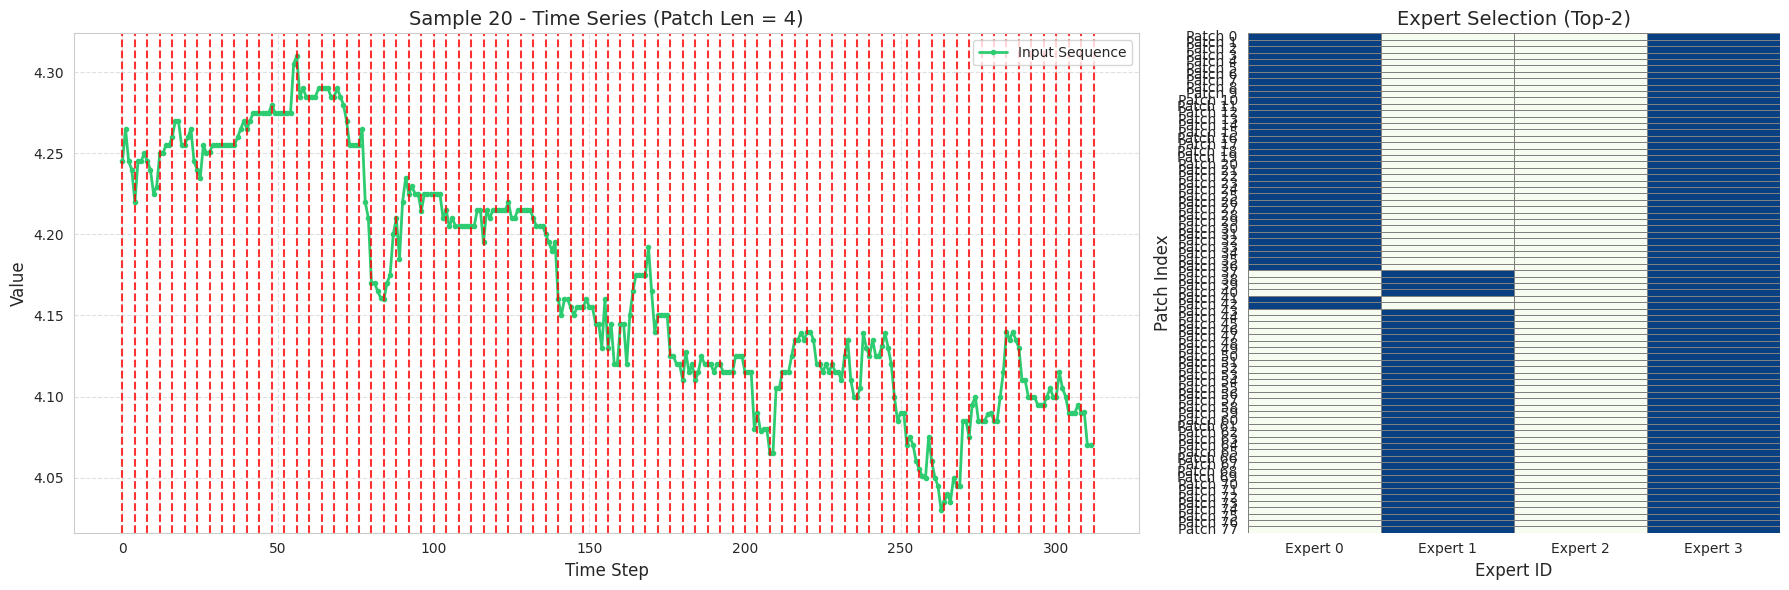

Saved plot to: ./output/Expert_Selection/socialgood_momep/sample_30.pdf


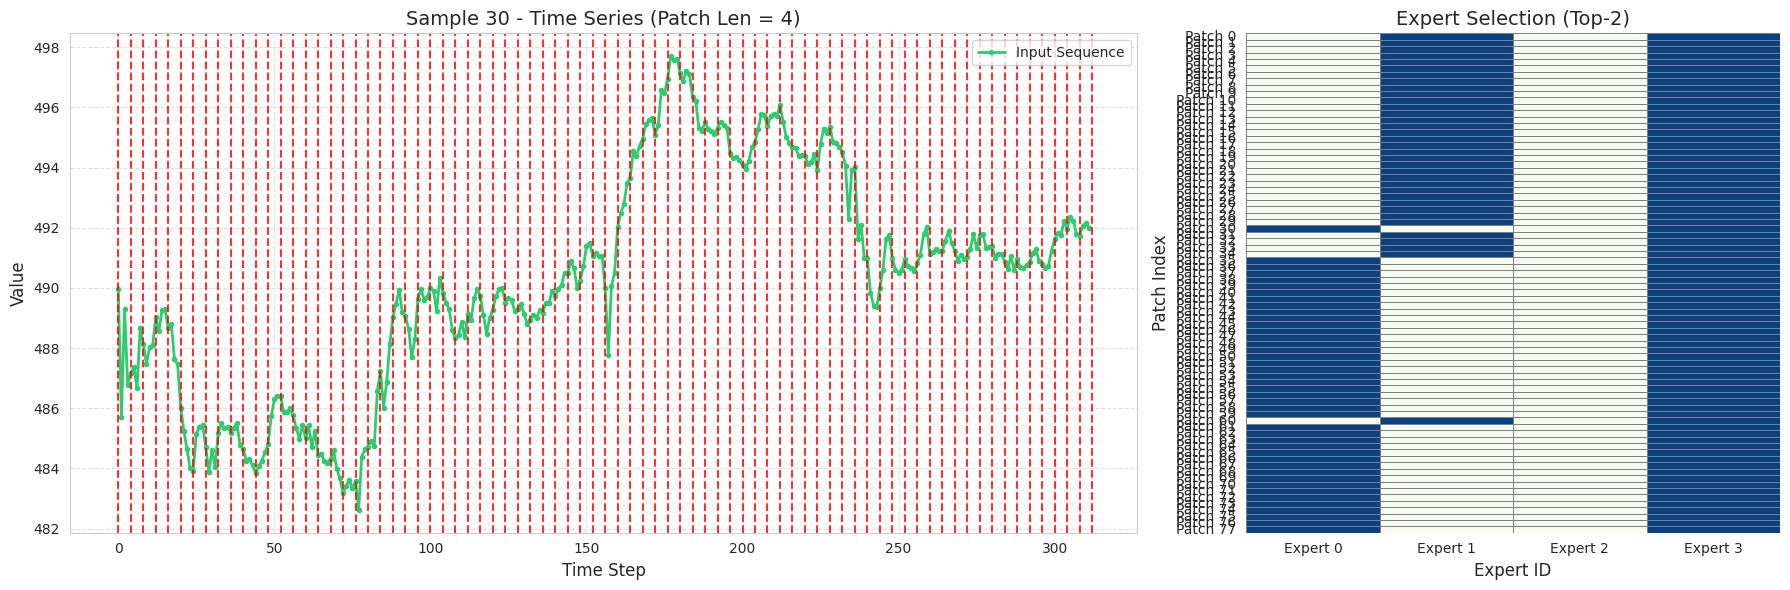

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_sample_with_expert_routing(
    result_dict,
    idx,
    patch_len=4,
    num_experts=4,
    save_path=None,
    sample_name="Sample"
):
    """
    Plot input time series with patch boundaries and expert selection heatmap side-by-side.
    
    Parameters:
    - result_dict: dict from npz file, must contain 'input_seq' and 'selected_experts'
    - idx: index of the sample to plot
    - patch_len: length of each patch (token)
    - num_experts: total number of experts
    - save_path: if provided, save figure as PDF (e.g., "sample_0.pdf")
    - sample_name: label for the title
    """
    # Extract data
    input_seq = result_dict['input_seq'][idx]      # [C, L] or [L]
    selected_experts = result_dict['selected_experts'][idx]  # [N, K]

    # Handle input_seq shape
    if input_seq.ndim == 2:
        y_vals = input_seq[0]  # take first channel
    else:
        y_vals = input_seq.squeeze()
    
    input_length = len(y_vals)
    N, K = selected_experts.shape  # N: num patches, K: top-k

    # --- Create one-hot mask for experts ---
    expert_indices = selected_experts.astype(int)
    one_hot = np.zeros((N, num_experts))
    for i in range(N):
        one_hot[i, expert_indices[i]] = 1

    # --- Plotting ---
    fig, axes = plt.subplots(1, 2, figsize=(18, 6), width_ratios=[2, 1])

    # Left: Time series with patch boundaries
    sns.set_style("whitegrid")
    axes[0].plot(
        np.arange(input_length), y_vals,
        color="#2ecc71", linewidth=2, marker="o", markersize=3,
        label="Input Sequence"
    )
    # Draw vertical lines at patch boundaries
    for i in range(0, input_length + 1, patch_len):
        if i <= input_length:
            axes[0].axvline(x=i, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    
    axes[0].set_title(f"{sample_name} - Time Series (Patch Len = {patch_len})", fontsize=14)
    axes[0].set_xlabel("Time Step", fontsize=12)
    axes[0].set_ylabel("Value", fontsize=12)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # Right: Expert selection heatmap
    sns.heatmap(
        one_hot,
        ax=axes[1],
        cmap="GnBu_r",
        cbar=False,
        xticklabels=[f"Expert {i}" for i in range(num_experts)],
        yticklabels=[f"Patch {i}" for i in range(N)],
        annot=False,
        linewidths=0.5,
        linecolor='gray'
    )
    axes[1].set_title("Expert Selection (Top-2)", fontsize=14)
    axes[1].set_xlabel("Expert ID", fontsize=12)
    axes[1].set_ylabel("Patch Index", fontsize=12)

    plt.tight_layout()

    # Save if path provided
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Saved plot to: {save_path}")
    
    plt.show()

# ----------------------------
# 使用示例
# ----------------------------
# 假设你已加载 result1
for idx in [1,2,3,8,10,15,20,30]:
    plot_sample_with_expert_routing(
        result_dict=result1,
        idx=idx,
        patch_len=4, # determined by trained_model
        num_experts=4, # determined by trained_model
        save_path=f"./output/Expert_Selection/socialgood_momep/sample_{idx}.pdf",
        sample_name=f"Sample {idx}"
    )